<a href="https://colab.research.google.com/github/vuongtran31251023271-code/Th-/blob/main/PALMCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/data_palm'

In [ ]:
data_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

x_train = data_train.flow_from_directory(
    path,
    target_size=(60, 60),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

x_test = data_train.flow_from_directory(
    path,
    target_size=(60, 60),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(x_train.class_indices)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
{'other': 0, 'person1': 1}


In [ ]:
num_classes = len(x_train.class_indices)

model = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(60,60,3)),
    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    epochs=30,
    validation_data=x_test
)

model.save('palm_model.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.6313 - loss: 0.5064 - val_accuracy: 1.0000 - val_loss: 0.1257
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 819ms/step - accuracy: 0.9062 - loss: 0.2752 - val_accuracy: 1.0000 - val_loss: 0.0599
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 819ms/step - accuracy: 0.9812 - loss: 0.0961 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9937 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 4.4882e-06
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 834ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 3.5763e-08
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 824ms/step - accuracy: 0.9937 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 1.4901e-08
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 1.0000 - loss: 3.1649e-05 - val_accuracy: 1.0000 - val_loss: 1.7881e-08
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 812ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000

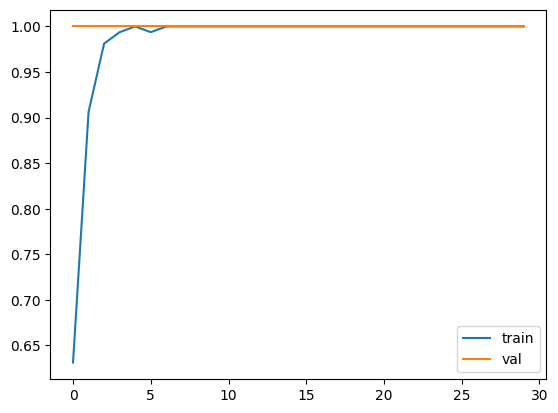

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.show()

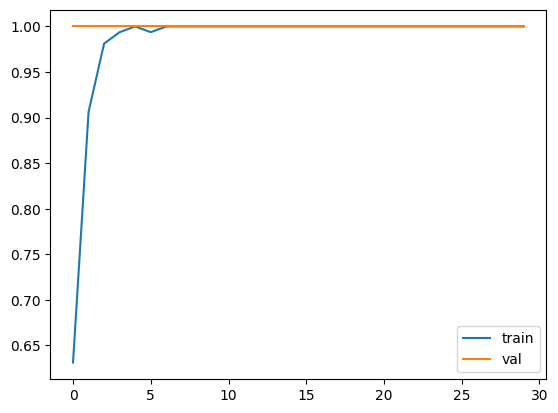

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.show()

In [ ]:
from tensorflow.keras.utils import load_img

img = load_img('/content/drive/MyDrive/test_chitay.JPG', target_size=(60,60))

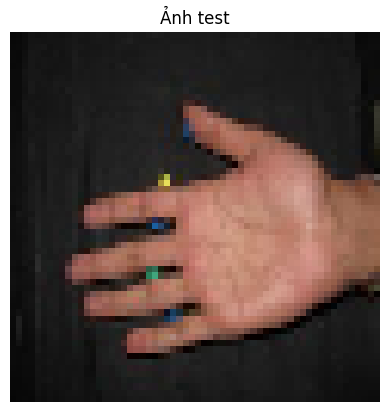

In [ ]:
plt.imshow(img)
plt.title("Ảnh test")
plt.axis('off')
plt.show()

In [ ]:
img = np.array(img) / 255.0
img = img.reshape(1,60,60,3)

In [ ]:
pred = model.predict(img)
label = np.argmax(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [ ]:
class_labels = {v:k for k,v in x_train.class_indices.items()}
result = class_labels[label]

print("Xác suất:", pred)
print("Label:", result)

Xác suất: [[1.3295819e-11 1.0000000e+00]]
Label: person1


In [ ]:
if class_labels[label] == "person1":
    print("✅ Đây là chỉ tay của bạn")
else:
    print("❌ Không phải bạn")

✅ Đây là chỉ tay của bạn
